## 1. Setup and Imports
Importing libraries for data handling (pandas, numpy), visualization (matplotlib, seaborn), and connecting to the Hopsworks Feature Store.

In [15]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import hopsworks

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
print("Libraries imported successfully")

Libraries imported successfully


## 2. Connect to Hopsworks Feature Store
Logging into the Hopsworks project to access the centralized Feature Store where all our AQI and weather data is stored.

In [16]:
project = hopsworks.login(
    api_key_value="gZvR3YByD8FXqMr8.jdC2AciLzhkSTATB8Vq0CUc3VtgU40SgVmjxakvvLSjrBK9BHFIh6GOyfZkcLLFk",
    project="PredictorAQI"
)
fs = project.get_feature_store()
print("Connected to Hopsworks Feature Store")

2026-05-29 21:02:53,792 INFO: Closing external client and cleaning up certificates.
2026-05-29 21:02:53,859 INFO: Connection closed.
2026-05-29 21:02:53,866 INFO: Initializing external client
2026-05-29 21:02:53,866 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-05-29 21:02:57,361 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/32023
Connected to Hopsworks Feature Store


## 3. Data Collection and Feature Storage
Fetching 6 months of historical hourly data: weather from Open-Meteo (temperature, humidity, wind, pressure) and pollution from Open-Meteo Air Quality (PM2.5, PM10, NO2, O3, SO2, CO). AQI is computed from PM2.5 using the US EPA formula. All engineered features are stored in the Hopsworks Feature Store.

In [17]:
import requests
from datetime import datetime, timedelta

LAT, LON, CITY = 24.8607, 67.0011, "karachi"
end_date = datetime.utcnow().date() - timedelta(days=1)
start_date = end_date - timedelta(days=180)

def get_aqi_category(aqi):
    if aqi <= 50: return "good"
    elif aqi <= 100: return "moderate"
    elif aqi <= 150: return "unhealthy_sensitive"
    elif aqi <= 200: return "unhealthy"
    elif aqi <= 300: return "very_unhealthy"
    else: return "hazardous"

def pm25_to_aqi(pm):
    bp = [(0,12,0,50),(12.1,35.4,51,100),(35.5,55.4,101,150),
          (55.5,150.4,151,200),(150.5,250.4,201,300),
          (250.5,350.4,301,400),(350.5,500.4,401,500)]
    for cl,ch,il,ih in bp:
        if cl <= pm <= ch:
            return round((ih-il)/(ch-cl)*(pm-cl)+il)
    return 500 if pm > 500.4 else 0

# Weather from Open-Meteo
print("Fetching weather...")
w = requests.get("https://archive-api.open-meteo.com/v1/archive", params={
    "latitude": LAT, "longitude": LON,
    "start_date": start_date.strftime("%Y-%m-%d"),
    "end_date": end_date.strftime("%Y-%m-%d"),
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure",
    "format": "json"
}, timeout=60).json()["hourly"]
weather_df = pd.DataFrame({
    "timestamp": pd.to_datetime(w["time"]),
    "temperature": w["temperature_2m"],
    "humidity": [float(x) if x is not None else 0.0 for x in w["relative_humidity_2m"]],
    "wind": w["wind_speed_10m"],
    "pressure": w["surface_pressure"],
})
print(f"Weather: {len(weather_df)} rows")

# Pollution from Open-Meteo Air Quality
print("Fetching pollution...")
p = requests.get("https://air-quality-api.open-meteo.com/v1/air-quality", params={
    "latitude": LAT, "longitude": LON,
    "start_date": start_date.strftime("%Y-%m-%d"),
    "end_date": end_date.strftime("%Y-%m-%d"),
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide",
    "format": "json"
}, timeout=60).json()["hourly"]
pollution_df = pd.DataFrame({
    "timestamp": pd.to_datetime(p["time"]),
    "pm25": [float(x) if x is not None else 0.0 for x in p["pm2_5"]],
    "pm10": [float(x) if x is not None else 0.0 for x in p["pm10"]],
    "no2": [float(x) if x is not None else 0.0 for x in p["nitrogen_dioxide"]],
    "o3": [float(x) if x is not None else 0.0 for x in p["ozone"]],
    "so2": [float(x) if x is not None else 0.0 for x in p["sulphur_dioxide"]],
    "co": [float(x) if x is not None else 0.0 for x in p["carbon_monoxide"]],
})
print(f"Pollution: {len(pollution_df)} rows")

# Combine + engineer
df = pd.merge(pollution_df, weather_df, on="timestamp", how="inner")
df["aqi"] = df["pm25"].apply(pm25_to_aqi).astype(float)
df["hour"] = df["timestamp"].dt.hour.astype("int64")
df["day_of_week"] = df["timestamp"].dt.weekday.astype("int64")
df["month"] = df["timestamp"].dt.month.astype("int64")
df["is_weekend"] = (df["timestamp"].dt.weekday >= 5).astype("int64")
df["aqi_category"] = df["aqi"].apply(get_aqi_category)
df["city"] = CITY
df = df.fillna(0.0).drop_duplicates(subset=["city","timestamp"])
print(f"Final: {df.shape}")
print(f"AQI range: {df['aqi'].min()} to {df['aqi'].max()}, mean {df['aqi'].mean():.1f}")

# Store in Hopsworks Feature Store
try:
    old = fs.get_feature_group(name="aqi_features", version=1)
    old.delete()
    print("Old feature group deleted.")
except:
    pass

fg = fs.get_or_create_feature_group(
    name="aqi_features",
    version=1,
    primary_key=["city","timestamp"],
    description="Hourly AQI and weather features for Karachi",
    event_time="timestamp",
)
fg.insert(df, write_options={"wait_for_job": True})
print("Stored in Hopsworks Feature Store.")

Fetching weather...
Weather: 4344 rows
Fetching pollution...
Pollution: 4344 rows
Final: (4344, 18)
AQI range: 15.0 to 172.0, mean 90.0
Old feature group deleted.
Feature Group created successfully, explore it at 
https://eu-west.cloud.hopsworks.ai:443/p/32023/fs/20707/fg/41891


Uploading Dataframe: 100.00% |███████████████████████████| Rows 4344/4344 | Elapsed Time: 00:02 | Remaining Time: 00:00


Launching job: aqi_features_1_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://eu-west.cloud.hopsworks.ai:443/p/32023/jobs/named/aqi_features_1_offline_fg_materialization/executions
2026-05-29 21:33:22,916 INFO: Waiting for execution to finish. Current state: SUBMITTED. Final status: UNDEFINED
2026-05-29 21:33:26,189 INFO: Waiting for execution to finish. Current state: RUNNING. Final status: UNDEFINED
2026-05-29 21:35:12,980 INFO: Waiting for execution to finish. Current state: FINISHED. Final status: SUCCEEDED
2026-05-29 21:35:13,804 INFO: Waiting for log aggregation to finish.
2026-05-29 21:35:13,806 INFO: Execution finished successfully.
Stored in Hopsworks Feature Store.


## 4. Loading Data from Feature Store
Reading the stored data back from Hopsworks to confirm successful storage. Dataset contains 4344 rows and 18 features.

In [18]:
fg = fs.get_feature_group(name="aqi_features", version=1)
df = fg.read()
df["timestamp"] = pd.to_datetime(df["timestamp"])
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.64s) 
Dataset shape: (4344, 18)
Columns: ['timestamp', 'pm25', 'pm10', 'no2', 'o3', 'so2', 'co', 'temperature', 'humidity', 'wind', 'pressure', 'aqi', 'hour', 'day_of_week', 'month', 'is_weekend', 'aqi_category', 'city']


,timestamp,pm25,pm10,no2,o3,so2,co,temperature,humidity,wind,pressure,aqi,hour,day_of_week,month,is_weekend,aqi_category,city
0,2026-04-26 07:00:00+00:00,26.0,62.4,7.7,133.0,16.1,235.0,34.3,47.0,14.8,1006.8,80.0,7,6,4,1,moderate,karachi
1,2026-02-27 02:00:00+00:00,21.9,36.7,23.7,52.0,9.1,584.0,21.4,92.0,10.5,1008.2,72.0,2,4,2,0,moderate,karachi
2,2026-03-05 02:00:00+00:00,12.5,14.8,22.8,53.0,8.8,561.0,20.9,91.0,10.4,1013.5,52.0,2,3,3,0,moderate,karachi
3,2026-04-20 23:00:00+00:00,17.6,29.1,14.1,57.0,8.3,212.0,24.4,91.0,7.8,1007.0,63.0,23,0,4,0,moderate,karachi
4,2026-05-05 07:00:00+00:00,44.0,137.8,8.6,183.0,22.1,632.0,33.5,50.0,15.2,1006.7,122.0,7,1,5,0,unhealthy_sensitive,karachi


## 5. Basic Statistics
The dataset spans 6 months with no missing values. Average AQI is 90 (Moderate), ranging from 15 (Good) to 172 (Unhealthy), with a standard deviation of ~29 showing healthy variation in the data.

In [19]:
print("=== Dataset Info ===")
print(f"Total rows: {len(df)}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nAQI Statistics:")
print(df['aqi'].describe())
print(f"\nMissing values:")
print(df.isnull().sum())

=== Dataset Info ===
Total rows: 4344
Date range: 2025-11-29 00:00:00+00:00 to 2026-05-28 23:00:00+00:00

AQI Statistics:
count    4344.000000
mean       90.003223
std        28.703571
min        15.000000
25%        69.000000
50%        83.000000
75%       106.000000
max       172.000000
Name: aqi, dtype: float64

Missing values:
timestamp       0
pm25            0
pm10            0
no2             0
o3              0
so2             0
co              0
temperature     0
humidity        0
wind            0
pressure        0
aqi             0
hour            0
day_of_week     0
month           0
is_weekend      0
aqi_category    0
city            0
dtype: int64


## 6. AQI Distribution
Karachi's air is mostly Moderate (68%), with 23% Unhealthy for Sensitive Groups and only 2.4% Good. The histogram shows most values cluster around AQI 80, with a secondary peak near 150 representing pollution spikes.

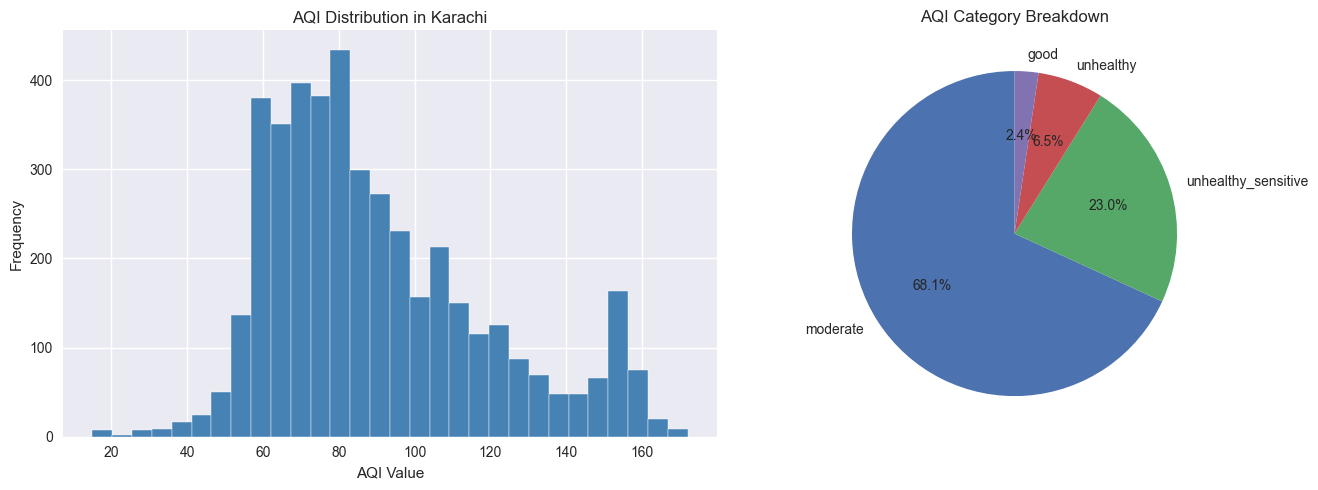

Chart saved.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['aqi'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('AQI Distribution in Karachi')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Frequency')

category_counts = df['aqi_category'].value_counts()
axes[1].pie(category_counts.values, labels=category_counts.index,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('AQI Category Breakdown')

plt.tight_layout()
plt.savefig('aqi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 7. AQI Over Time
A clear seasonal trend emerges: winter months (Dec-Jan) show frequent spikes above the unhealthy threshold of 150, while spring (Mar-Apr) air is noticeably cleaner. This reflects winter temperature inversions trapping pollutants near the ground.

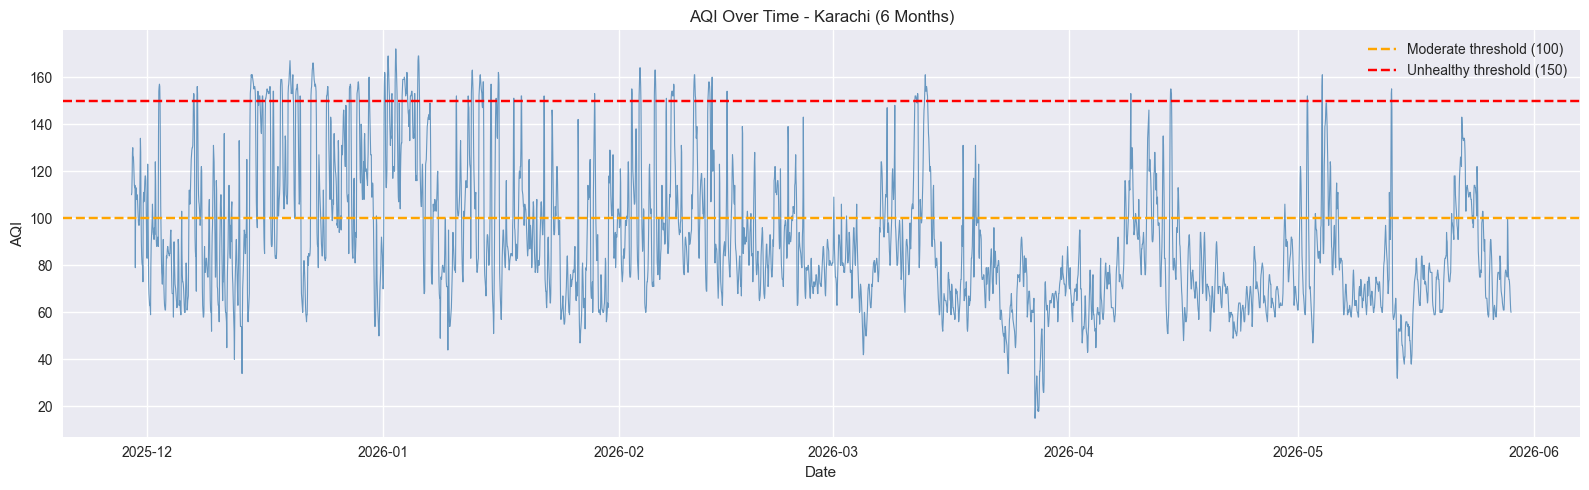

In [21]:
df_sorted = df.sort_values('timestamp')

plt.figure(figsize=(16, 5))
plt.plot(df_sorted['timestamp'], df_sorted['aqi'],
         color='steelblue', linewidth=0.8, alpha=0.8)
plt.axhline(y=100, color='orange', linestyle='--', label='Moderate threshold (100)')
plt.axhline(y=150, color='red', linestyle='--', label='Unhealthy threshold (150)')
plt.title('AQI Over Time - Karachi (6 Months)')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.savefig('aqi_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. AQI by Hour of Day
Air quality is worst at 3-4 AM (AQI ~103) when cool night air traps pollutants, and cleanest around noon (AQI ~79) when sunlight disperses them. A small secondary rise occurs in the evening rush hour.

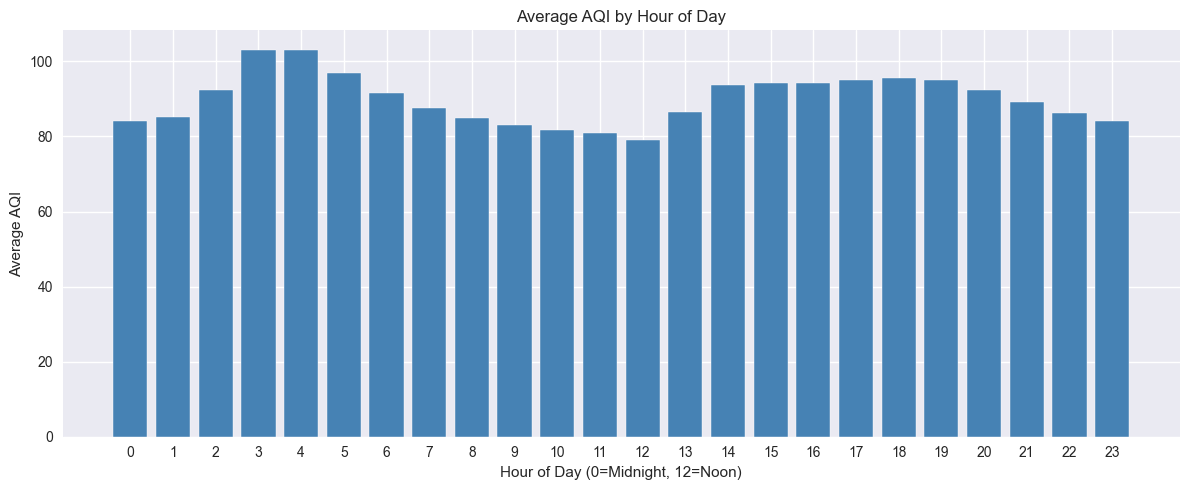

Worst hour: 3:00 (AQI: 103.1)
Best hour:  12:00 (AQI: 79.1)


In [22]:
hourly_avg = df.groupby('hour')['aqi'].mean()

plt.figure(figsize=(12, 5))
plt.bar(hourly_avg.index, hourly_avg.values, color='steelblue', edgecolor='white')
plt.title('Average AQI by Hour of Day')
plt.xlabel('Hour of Day (0=Midnight, 12=Noon)')
plt.ylabel('Average AQI')
plt.xticks(range(24))
plt.tight_layout()
plt.savefig('aqi_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Worst hour: {hourly_avg.idxmax()}:00 (AQI: {hourly_avg.max():.1f})")
print(f"Best hour:  {hourly_avg.idxmin()}:00 (AQI: {hourly_avg.min():.1f})")

## 9. AQI by Day of Week
AQI stays fairly constant across all days (88-92), with weekdays and weekends nearly identical. This indicates pollution is driven more by weather and industry than by weekday traffic.

2026-05-30 00:56:04,017 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-30 00:56:04,023 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


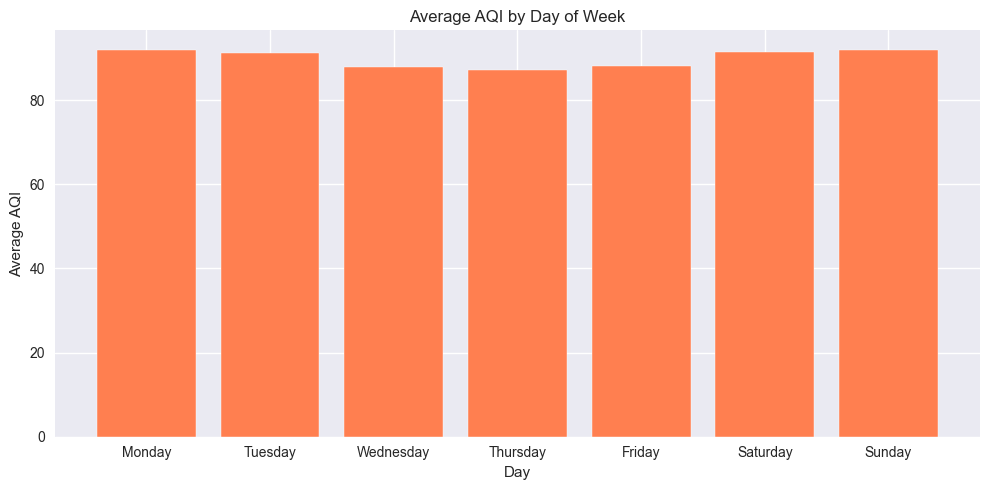

In [23]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg = df.groupby('day_of_week')['aqi'].mean()

plt.figure(figsize=(10, 5))
plt.bar(days, daily_avg.values, color='coral', edgecolor='white')
plt.title('Average AQI by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average AQI')
plt.tight_layout()
plt.savefig('aqi_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. AQI by Month
November is the worst month (AQI ~ 108), followed by December and January. Spring months (March-May) are significantly cleaner (~76-80), confirming the strong seasonal winter pollution pattern.

2026-05-30 01:02:19,101 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-30 01:02:19,102 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


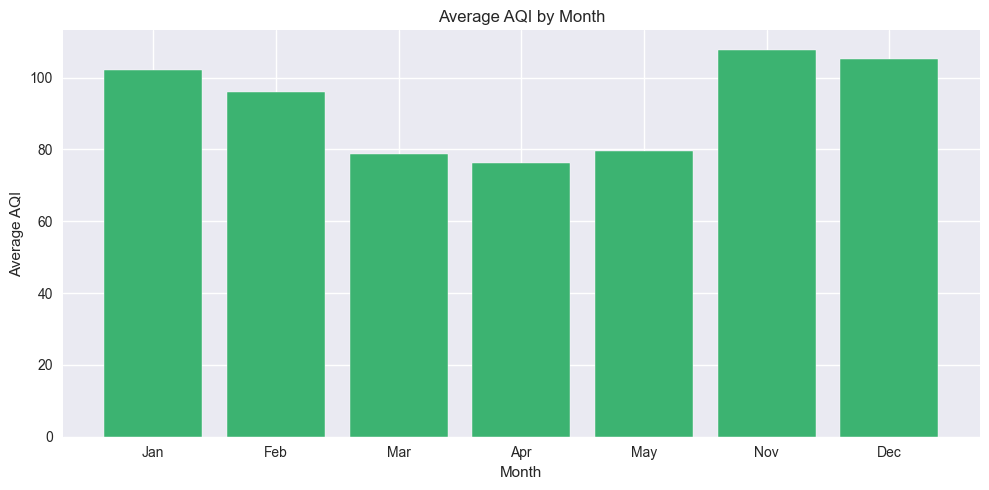

In [24]:
monthly_avg = df.groupby('month')['aqi'].mean()
month_names = {11: 'Nov', 12: 'Dec', 1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May'}

plt.figure(figsize=(10, 5))
plt.bar([month_names.get(m, str(m)) for m in monthly_avg.index],
        monthly_avg.values, color='mediumseagreen', edgecolor='white')
plt.title('Average AQI by Month')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.tight_layout()
plt.savefig('aqi_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Feature Correlation Heatmap
PM2.5 correlates almost perfectly with AQI (0.99), confirming it as the dominant driver. CO, PM10, and NO2 show moderate positive correlation, while wind and temperature are negatively correlated; windier, warmer conditions mean cleaner air.

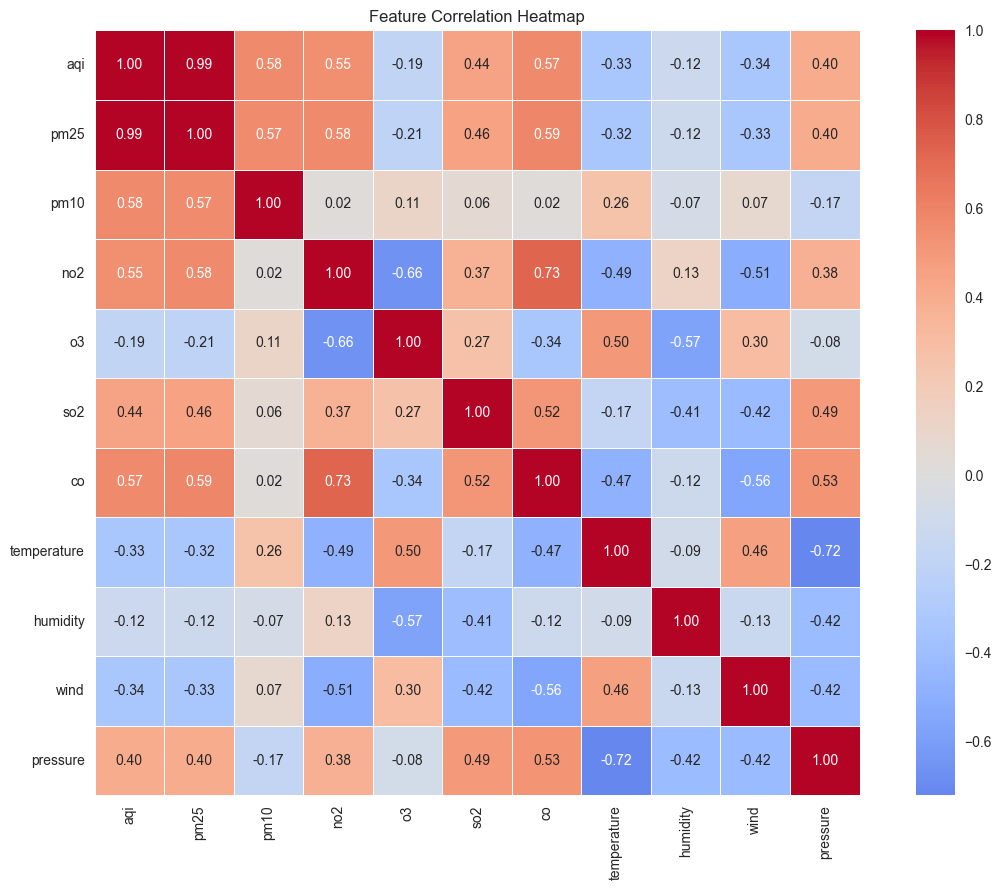

In [25]:
numeric_cols = ['aqi', 'pm25', 'pm10', 'no2', 'o3', 'so2', 'co',
                'temperature', 'humidity', 'wind', 'pressure']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Pollutant and Weather Relationships
PM2.5 shows a near-linear relationship with AQI. Wind speed clearly pushes AQI down as it disperses pollutants. Temperature and humidity show weaker, scattered relationships, contributing minor signal to predictions.

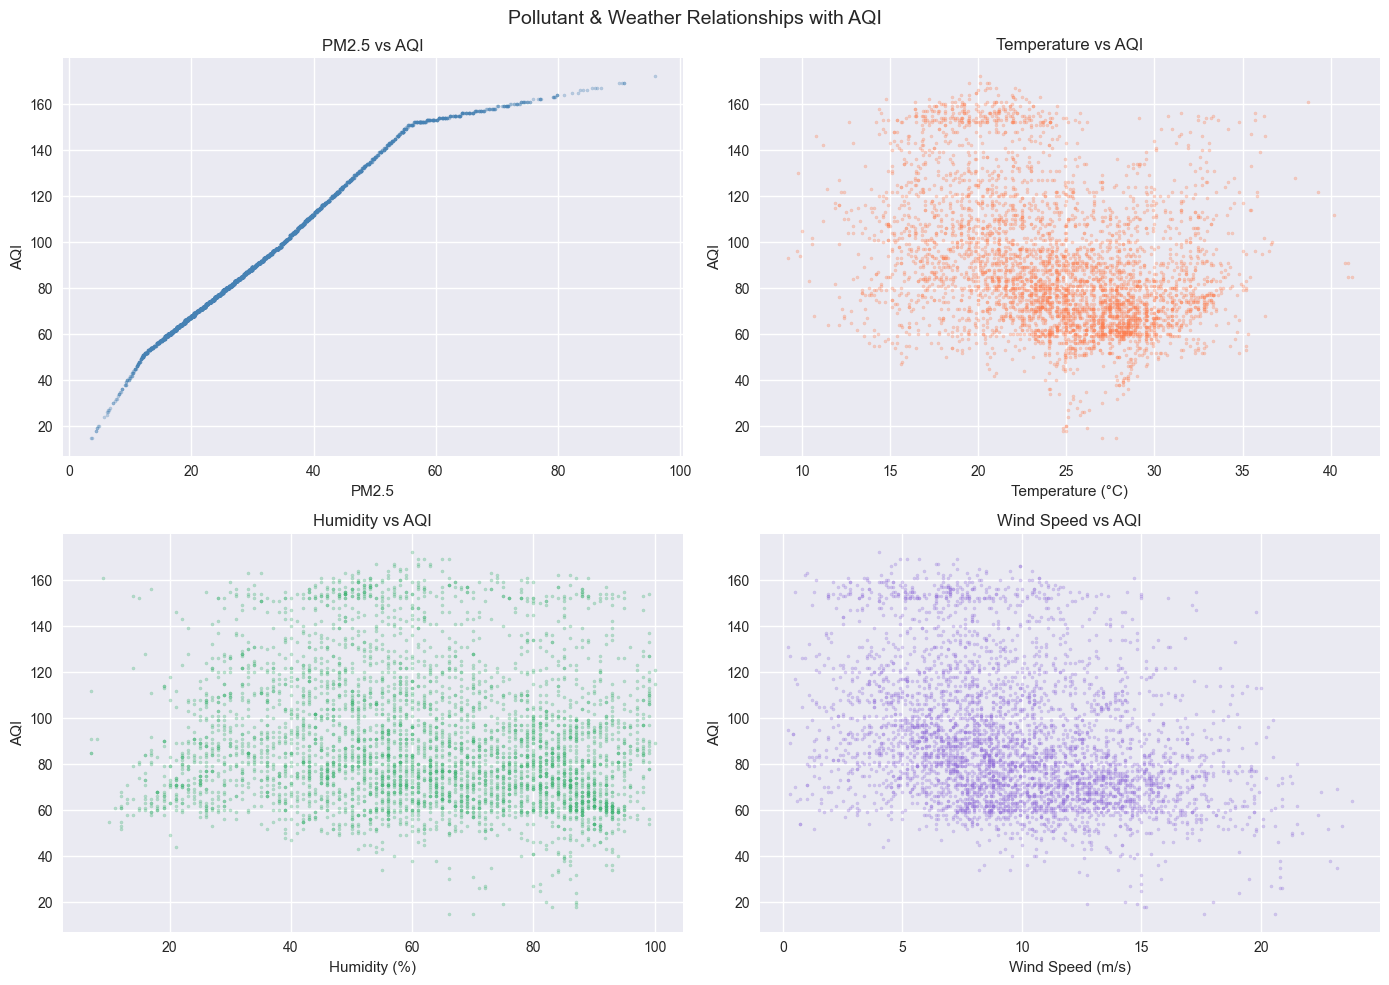

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(df['pm25'], df['aqi'], alpha=0.3, color='steelblue', s=5)
axes[0,0].set_xlabel('PM2.5')
axes[0,0].set_ylabel('AQI')
axes[0,0].set_title('PM2.5 vs AQI')

axes[0,1].scatter(df['temperature'], df['aqi'], alpha=0.3, color='coral', s=5)
axes[0,1].set_xlabel('Temperature (°C)')
axes[0,1].set_ylabel('AQI')
axes[0,1].set_title('Temperature vs AQI')

axes[1,0].scatter(df['humidity'], df['aqi'], alpha=0.3, color='mediumseagreen', s=5)
axes[1,0].set_xlabel('Humidity (%)')
axes[1,0].set_ylabel('AQI')
axes[1,0].set_title('Humidity vs AQI')

axes[1,1].scatter(df['wind'], df['aqi'], alpha=0.3, color='mediumpurple', s=5)
axes[1,1].set_xlabel('Wind Speed (m/s)')
axes[1,1].set_ylabel('AQI')
axes[1,1].set_title('Wind Speed vs AQI')

plt.suptitle('Pollutant & Weather Relationships with AQI', fontsize=14)
plt.tight_layout()
plt.savefig('pollutant_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Weekday vs Weekend
Weekends (91.8) are marginally worse than weekdays (89.3), but the difference is negligible. This confirms Karachi's pollution is not primarily traffic-driven on a weekly cycle.

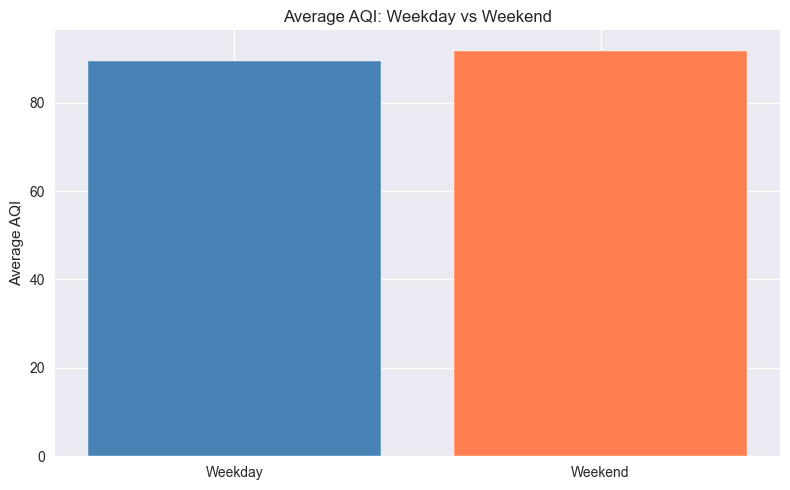

Weekday average AQI: 89.3
Weekend average AQI: 91.8


In [27]:
weekend_avg = df.groupby('is_weekend')['aqi'].mean()
labels = ['Weekday', 'Weekend']

plt.figure(figsize=(8, 5))
plt.bar(labels, weekend_avg.values, color=['steelblue', 'coral'], edgecolor='white')
plt.title('Average AQI: Weekday vs Weekend')
plt.ylabel('Average AQI')
plt.tight_layout()
plt.savefig('weekend_vs_weekday.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Weekday average AQI: {weekend_avg[0]:.1f}")
print(f"Weekend average AQI: {weekend_avg[1]:.1f}")

## 14. Key Insights Summary
Final summary of EDA findings: 4344 data points, average AQI 90, unhealthy 6.5% of the time, worst at 3 AM and in November, with PM2.5 as the most predictive feature for modeling.

In [28]:
print("=" * 50)
print("KEY INSIGHTS FROM EDA")
print("=" * 50)
print(f"Total data points: {len(df)}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Average AQI: {df['aqi'].mean():.1f}")
print(f"Max AQI: {df['aqi'].max():.1f}")
print(f"Min AQI: {df['aqi'].min():.1f}")
print(f"% of time Unhealthy (AQI>150): {(df['aqi']>150).mean()*100:.1f}%")
print(f"Worst hour of day: {df.groupby('hour')['aqi'].mean().idxmax()}:00")
print(f"Worst month: {df.groupby('month')['aqi'].mean().idxmax()}")
print(f"Most correlated pollutant with AQI: pm25")
print("=" * 50)

KEY INSIGHTS FROM EDA
Total data points: 4344
Date range: 2025-11-29 00:00:00+00:00 to 2026-05-28 23:00:00+00:00
Average AQI: 90.0
Max AQI: 172.0
Min AQI: 15.0
% of time Unhealthy (AQI>150): 6.5%
Worst hour of day: 3:00
Worst month: 11
Most correlated pollutant with AQI: pm25
